https://www.kaggle.com/datasets/anacartola/the-barbie-cinematographic-universe-barbieverse

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [41]:
df=pd.read_csv('Barbieverse Characters.csv')

In [42]:
df.head()

,No. Movie,No. Character,Character Name,Barbie Cast,Skin Tone,Eyes,Hair,Gender,Race,Speaking Voice,Singing Voice
0,1,1,Barbie,Barbie,Light Medium,Blue,Blonde,Female,Human,Kelly Sheridan,NaN
1,1,2,Aunt Drosselmayer,NaN,Light,Green,Brown,Female,Human,Kathleen Barr,NaN
2,1,3,Captain Candy,NaN,Medium Deep,Deep,Brown,Male,Human,Ian James Corlett,NaN
3,1,4,Clara,Barbie,Light Medium,Blue,Blonde,Female,Human,Kelly Sheridan,NaN
4,1,5,Flower Faeries,NaN,Light Medium,Multicolor,Multicolor,Female,Flower Fairy,Shona Galbraith,NaN


In [43]:
df.tail()

,No. Movie,No. Character,Character Name,Barbie Cast,Skin Tone,Eyes,Hair,Gender,Race,Speaking Voice,Singing Voice
882,42,738,Scary Monster,NaN,NaN,NaN,NaN,Male,NaN,Ritesh Rajan,NaN
883,42,739,Tammy,NaN,Light Medium,Brown,Dark Brown,Female,Human,Kirsten Day,NaN
884,42,740,Tough Jock,NaN,NaN,NaN,NaN,Male,Human,Ritesh Rajan,NaN
885,42,741,Trucker Pete,NaN,Light,Green,Redhair,Male,Human,Bill Rogers,NaN
886,42,742,Zincenzio Dracula,NaN,NaN,NaN,NaN,NaN,NaN,Greg Chun,NaN


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   No.  Movie      887 non-null    int64 
 1   No. Character   887 non-null    int64 
 2   Character Name  887 non-null    object
 3   Barbie Cast     139 non-null    object
 4   Skin Tone       680 non-null    object
 5   Eyes            738 non-null    object
 6   Hair            718 non-null    object
 7   Gender          864 non-null    object
 8   Race            844 non-null    object
 9   Speaking Voice  862 non-null    object
 10  Singing Voice   27 non-null     object
dtypes: int64(2), object(9)
memory usage: 76.4+ KB


In [45]:
df.columns

Index(['No.  Movie', 'No. Character', 'Character Name', 'Barbie Cast',
       'Skin Tone', 'Eyes', 'Hair', 'Gender', 'Race', 'Speaking Voice',
       'Singing Voice'],
      dtype='object')

In [46]:
df.columns = df.columns.str.strip()
df = df.drop_duplicates()
df['Character Name'] = df['Character Name'].str.strip()

In [47]:
barbie_count = df[df['Character Name'].str.contains("Barbie", case=False)].shape[0]
total_characters = df.shape[0]
barbie_percentage = (barbie_count / total_characters) * 100
print(barbie_percentage)

3.269447576099211


In [48]:
top_characters = df['Character Name'].value_counts().head(10)
print(top_characters)

Barbie      20
Chelsea     14
Stacie      13
Skipper     11
Ken          6
George       6
Elina        5
Teresa       5
Margaret     5
Raquelle     4
Name: Character Name, dtype: int64


In [49]:
barbie_movies = df[df['Character Name']=="Barbie"]['No.  Movie'].nunique()
total_movies = df['No.  Movie'].nunique()

In [50]:
gender_distribution = df['Gender'].value_counts()
gender_distribution

Female    513
Male      350
Male        1
Name: Gender, dtype: int64

In [51]:
race_distribution = df['Race'].value_counts()
race_distribution

Human             530
Mermaid            43
Dog                32
Fairy              23
Horse              12
                 ... 
Flutterpixie        1
Meewah              1
Flying Serpent      1
Purse Fairy         1
Tiki Statue         1
Name: Race, Length: 85, dtype: int64

In [52]:
skin_distribution = df['Skin Tone'].value_counts()
skin_distribution

Light Medium         410
Light                114
Medium                53
Deep                  18
Medium Deep           18
Green                 16
Pink                  14
Purple                10
Brown                  5
Yellow                 4
Gray                   3
Blue                   3
White                  3
Purple and Yellow      2
Light Purple           1
Yellow and Green       1
Teal                   1
Green and Blue         1
Orange                 1
Dark Pink              1
White and Purple       1
Name: Skin Tone, dtype: int64

In [53]:
hair_counts = df['Hair'].value_counts()
hair_counts

Brown           189
Blonde          157
Dark             43
Gray             37
Dark Brown       26
               ... 
White/Peach       1
Dark Blue         1
Medium Brown      1
Multicolor        1
Dark Pink         1
Name: Hair, Length: 72, dtype: int64

In [54]:
eye_counts = df['Eyes'].value_counts()
eye_counts

Blue            267
Brown           264
Green            95
Purple           21
Light Brown      13
Deep             12
Light Blue       11
Teal              8
Yellow            7
Deep Blue         7
Gray              7
Light Green       5
Black             4
Light Teal        3
Red               3
Hazel             2
Pink              2
Amber             2
Yellow/Blue       1
Deep Brown        1
Light Purple      1
Black/Green       1
Multicolor        1
Name: Eyes, dtype: int64

In [55]:
voice_counts = df['Speaking Voice'].value_counts().head(10)
voice_counts 

Kelly Sheridan         40
Kathleen Barr          39
Tabitha St. Germain    33
Nicole Oliver          16
Michael Dobson         15
Brian Drummond         13
Greg Chun              12
Cathy Weseluck         12
Maryke Hendrikse       12
Alistair Abell         11
Name: Speaking Voice, dtype: int64

In [56]:
df['Is_Barbie'] = df['Character Name'].str.contains("Barbie")
barbie_vs_others = df['Is_Barbie'].value_counts()
barbie_vs_others

False    858
True      29
Name: Is_Barbie, dtype: int64

In [57]:
characters_per_movie = df.groupby('No.  Movie')['Character Name'].count()

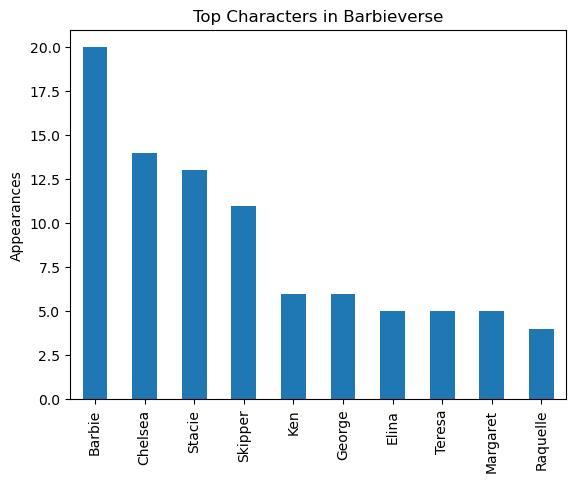

In [58]:
top_characters.plot(kind="bar")
plt.title("Top Characters in Barbieverse")
plt.ylabel("Appearances")
plt.show()

In [59]:
timeline_df = df[['No.  Movie','Character Name','Skin Tone','Hair','Gender','Race']]
timeline_df = timeline_df.dropna(subset=['Character Name'])
timeline_df.head()

,No. Movie,Character Name,Skin Tone,Hair,Gender,Race
0,1,Barbie,Light Medium,Blonde,Female,Human
1,1,Aunt Drosselmayer,Light,Brown,Female,Human
2,1,Captain Candy,Medium Deep,Brown,Male,Human
3,1,Clara,Light Medium,Blonde,Female,Human
4,1,Flower Faeries,Light Medium,Multicolor,Female,Flower Fairy


In [60]:
import plotly.express as px
fig = px.scatter(
    timeline_df,
    x="No.  Movie",
    y="Character Name",
    color="Skin Tone",
    hover_data=["Hair","Gender","Race"],
    title="Barbie Character Evolution Timeline"
)
fig.update_layout(
    height=700,
    xaxis_title="Barbie Movie Timeline",
    yaxis_title="Character Name"
)
fig.show()